<a href="https://colab.research.google.com/github/Manikanta2804/RL_ASSESMENTS_2303A51458_B_07/blob/main/RL_ASSESMENT_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Implementation of Random Agent

First, let's install the necessary libraries: `gymnasium` (a fork of OpenAI Gym, which is a toolkit for developing and comparing reinforcement learning algorithms) and `pygame` (for rendering some environments, particularly FrozenLake).

In [1]:
import sys

# Install gymnasium and pygame
!{sys.executable} -m pip install gymnasium==0.29.1 pygame==2.5.2

import gymnasium as gym
import random
import numpy as np
import time

print("Libraries installed and imported successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 42.6 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
Libraries installed and imported successfully!


### 1. CartPole Environment

Let's start with the CartPole environment. The goal is to balance a pole on a cart by moving the cart left or right.

Here's how we'll implement the random agent for CartPole:

1.  **Create the environment**: We'll use `gym.make('CartPole-v1')`.
2.  **Define a function for a single episode**: This function will encapsulate the logic for one run of the agent in the environment.
3.  **Reset the environment**: At the beginning of each episode.
4.  **Loop until episode terminates**: In each step:
    *   **Identify available actions**: CartPole has a discrete action space (0 for left, 1 for right).
    *   **Select an action randomly**: `env.action_space.sample()` is perfect for this.
    *   **Execute the action**: `env.step(action)`.
    *   **Observe next state and reward**.
5.  **Calculate and display total reward** for the episode.

After defining the single episode, we will run multiple episodes and calculate the average reward.

In [2]:
def run_cartpole_episode(env, render=False):
    """Runs a single episode of the CartPole environment with a random agent."""
    observation, info = env.reset() # Reset the environment to get initial state
    total_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        if render:
            env.render()
        action = env.action_space.sample() # Randomly select an action
        observation, reward, terminated, truncated, info = env.step(action) # Execute the action
        total_reward += reward

    return total_reward

# Create the CartPole environment
cartpole_env = gym.make('CartPole-v1', render_mode='human') # Use 'human' for rendering

num_episodes = 10
rewards = []

print(f"Running {num_episodes} episodes for CartPole-v1...")
for i in range(num_episodes):
    episode_reward = run_cartpole_episode(cartpole_env, render=False) # Set render=True to see the simulation
    rewards.append(episode_reward)
    print(f"Episode {i+1}: Total Reward = {episode_reward}")

# Close the environment after all episodes
cartpole_env.close()

average_reward = np.mean(rewards)
print(f"\nAverage reward over {num_episodes} CartPole episodes: {average_reward:.2f}")

Running 10 episodes for CartPole-v1...
Episode 1: Total Reward = 14.0
Episode 2: Total Reward = 13.0
Episode 3: Total Reward = 15.0
Episode 4: Total Reward = 17.0
Episode 5: Total Reward = 16.0
Episode 6: Total Reward = 33.0
Episode 7: Total Reward = 11.0
Episode 8: Total Reward = 13.0
Episode 9: Total Reward = 13.0
Episode 10: Total Reward = 32.0

Average reward over 10 CartPole episodes: 17.70


### 2. MountainCar Environment

Next, let's tackle the MountainCar environment. In this environment, a car is at the bottom of a valley and needs to drive up a steep hill to reach a flag on the right. The car's engine isn't powerful enough to drive straight up, so it needs to go back and forth to build up momentum.

We'll use a similar approach as CartPole:

1.  **Create the environment**: `gym.make('MountainCar-v0')`.
2.  **Run multiple episodes** with a random agent.
3.  **Calculate and display total reward and average reward**.

In [3]:
def run_mountaincar_episode(env, render=False):
    """Runs a single episode of the MountainCar environment with a random agent."""
    observation, info = env.reset()
    total_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        if render:
            env.render()
        action = env.action_space.sample() # Randomly select an action
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

    return total_reward

# Create the MountainCar environment
mountaincar_env = gym.make('MountainCar-v0', render_mode='rgb_array') # 'rgb_array' for non-interactive rendering

num_episodes = 10
rewards = []

print(f"Running {num_episodes} episodes for MountainCar-v0...")
for i in range(num_episodes):
    episode_reward = run_mountaincar_episode(mountaincar_env, render=False) # Set render=True to see the simulation
    rewards.append(episode_reward)
    print(f"Episode {i+1}: Total Reward = {episode_reward}")

mountaincar_env.close()

average_reward = np.mean(rewards)
print(f"\nAverage reward over {num_episodes} MountainCar episodes: {average_reward:.2f}")

Running 10 episodes for MountainCar-v0...
Episode 1: Total Reward = -200.0
Episode 2: Total Reward = -200.0
Episode 3: Total Reward = -200.0
Episode 4: Total Reward = -200.0
Episode 5: Total Reward = -200.0
Episode 6: Total Reward = -200.0
Episode 7: Total Reward = -200.0
Episode 8: Total Reward = -200.0
Episode 9: Total Reward = -200.0
Episode 10: Total Reward = -200.0

Average reward over 10 MountainCar episodes: -200.00


### 3. FrozenLake Environment

Finally, let's implement the random agent for the FrozenLake environment. This is a grid-world environment where the agent must navigate from a start tile (S) to a goal tile (G) across a frozen lake. Some tiles are safe (F for frozen), while others are holes (H). Falling into a hole ends the episode with zero reward. The agent receives a reward of 1 for reaching the goal.

FrozenLake can be a bit tricky due to its stochastic nature (actions don't always result in the intended movement) and the presence of holes. We'll use `is_slippery=False` to make it deterministic for easier understanding initially, and then potentially `is_slippery=True` for the standard challenge. We'll also use `render_mode='ansi'` to print the game state to the console, or `human` to visualize it.

We'll follow the same pattern:

1.  **Create the environment**: `gym.make('FrozenLake-v1', is_slippery=False)`.
2.  **Run multiple episodes** with a random agent.
3.  **Calculate and display total reward and average reward**.

In [4]:
def run_frozenlake_episode(env, render=False):
    """Runs a single episode of the FrozenLake environment with a random agent."""
    observation, info = env.reset()
    total_reward = 0
    terminated = False
    truncated = False

    while not terminated and not truncated:
        if render:
            # Clear previous output for cleaner rendering in console
            # For 'ansi' render_mode, printing the frame is how it's done.
            # For 'human', env.render() directly updates the window.
            if env.render_mode == 'ansi':
                # This is a simple way to clear the console output in Colab
                # for 'ansi' rendering. In a real terminal, you might use os.system('clear').
                print("\033[H\033[J") # Clear screen and move cursor to home
                env.render()
                time.sleep(0.5) # Pause to see the frame
            else: # for 'human' or 'rgb_array'
                env.render()

        action = env.action_space.sample() # Randomly select an action
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

    return total_reward

# Create the FrozenLake environment
# Use is_slippery=False for a deterministic environment initially
# render_mode='ansi' for console output, 'human' for pop-up window, 'rgb_array' for images
frozenlake_env = gym.make('FrozenLake-v1', is_slippery=False, render_mode='ansi')

num_episodes = 100 # FrozenLake can be harder, run more episodes
rewards = []

print(f"Running {num_episodes} episodes for FrozenLake-v1 (is_slippery=False)...")
for i in range(num_episodes):
    episode_reward = run_frozenlake_episode(frozenlake_env, render=False) # Set render=True to see the simulation
    rewards.append(episode_reward)
    # print(f"Episode {i+1}: Total Reward = {episode_reward}") # Uncomment for per-episode rewards

frozenlake_env.close()

average_reward = np.mean(rewards)
print(f"\nAverage reward over {num_episodes} FrozenLake episodes: {average_reward:.2f}")

# Optional: Try with slippery environment
print("\n--- Running with is_slippery=True ---")
frozenlake_slippery_env = gym.make('FrozenLake-v1', is_slippery=True, render_mode='ansi')

num_episodes_slippery = 1000 # More episodes needed for stochastic environments
rewards_slippery = []

print(f"Running {num_episodes_slippery} episodes for FrozenLake-v1 (is_slippery=True)...")
for i in range(num_episodes_slippery):
    episode_reward = run_frozenlake_episode(frozenlake_slippery_env, render=False)
    rewards_slippery.append(episode_reward)

frozenlake_slippery_env.close()

average_reward_slippery = np.mean(rewards_slippery)
print(f"\nAverage reward over {num_episodes_slippery} slippery FrozenLake episodes: {average_reward_slippery:.2f}")

Running 100 episodes for FrozenLake-v1 (is_slippery=False)...

Average reward over 100 FrozenLake episodes: 0.00

--- Running with is_slippery=True ---
Running 1000 episodes for FrozenLake-v1 (is_slippery=True)...

Average reward over 1000 slippery FrozenLake episodes: 0.01


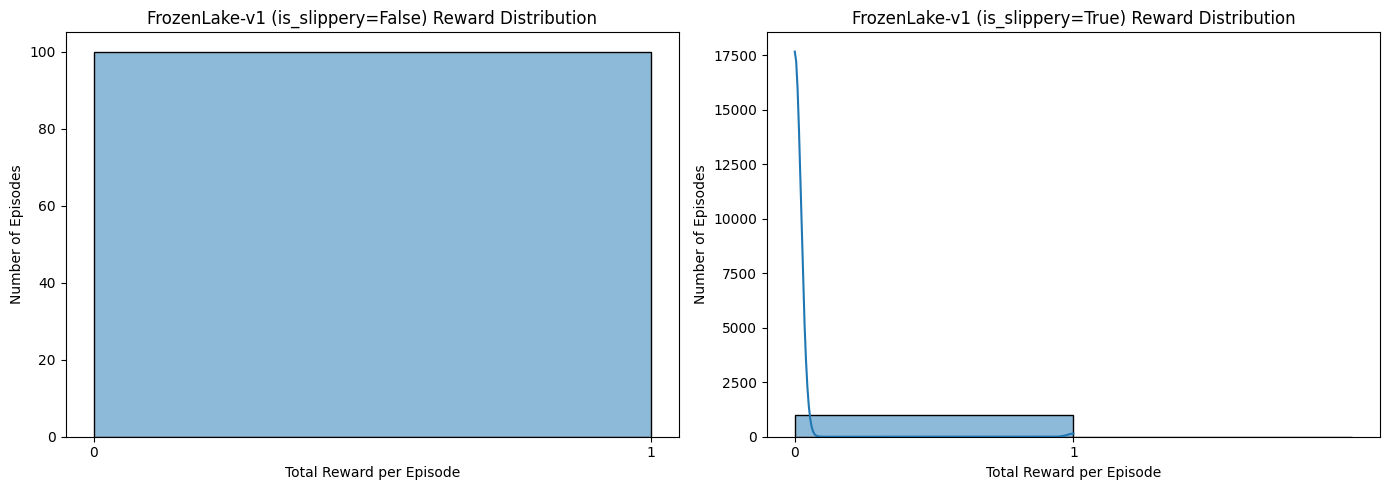

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for the two histograms
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for non-slippery FrozenLake
sns.histplot(rewards, bins=range(int(max(rewards)) + 2), ax=axes[0], kde=True)
axes[0].set_title('FrozenLake-v1 (is_slippery=False) Reward Distribution')
axes[0].set_xlabel('Total Reward per Episode')
axes[0].set_ylabel('Number of Episodes')
axes[0].set_xticks([0, 1]) # Assuming rewards are either 0 or 1 for FrozenLake

# Histogram for slippery FrozenLake
sns.histplot(rewards_slippery, bins=range(int(max(rewards_slippery)) + 2), ax=axes[1], kde=True)
axes[1].set_title('FrozenLake-v1 (is_slippery=True) Reward Distribution')
axes[1].set_xlabel('Total Reward per Episode')
axes[1].set_ylabel('Number of Episodes')
axes[1].set_xticks([0, 1]) # Assuming rewards are either 0 or 1 for FrozenLake

plt.tight_layout()
plt.show()